# 

## Portfolio Optimization Thesis

**Author:** Jean Jacques Kamdem  
**Matrikelnummer:** 548153  

**Topic:** Portfolio Optimization using Machine Learning and Volatility Models  

---

## Description

This notebook is part of a structured project investigating portfolio optimization.

It focuses on:
- Real financial data (yfinance)
- Portfolio optimization with real returns
---

# Markowitz Portfolio Optimization with Real Data

In diesem Notebook wenden wir die Markowitz-Portfolio-Theorie auf reale Finanzdaten an.

Während im vorherigen Notebook Simulationen verwendet wurden, nutzen wir nun echte Marktdaten aus Yahoo Finance.

Ziel ist es, ein realistisches optimales Portfolio zu bestimmen.

## Bibliotheken importieren

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

## Reale Finanzdaten laden

Wir laden historische Preisdaten verschiedener Anlageklassen.

In [6]:
assets = ["SPY", "QQQ", "TLT", "GLD", "VNQ"]

data = yf.download(assets, start="2015-01-01")

# Wir verwenden die Schlusskurse (Close Prices)
data = data["Close"]

data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,GLD,QQQ,SPY,TLT,VNQ
Date,,,,,
2015-01-02,114.080002,94.784401,170.125031,94.086510,53.111614
2015-01-05,115.800003,93.394089,167.052582,95.564476,53.402317
2015-01-06,117.120003,92.141815,165.479141,97.286224,53.932003
2015-01-07,116.430000,93.329597,167.541168,97.094147,54.758862
2015-01-08,115.940002,95.115936,170.514191,95.808350,54.965553


## Renditen berechnen

Die Renditen messen die relative Veränderung der Preise zwischen zwei Zeitpunkten.

Formel:
R_t = (P_t / P_{t-1}) - 1

In [8]:
returns = data.pct_change()
returns.head()

Ticker,GLD,QQQ,SPY,TLT,VNQ
Date,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN
2015-01-05,0.015077,-0.014668,-0.018060,0.015709,0.005473
2015-01-06,0.011399,-0.013408,-0.009419,0.018017,0.009919
2015-01-07,-0.005891,0.012891,0.012461,-0.001974,0.015332
2015-01-08,-0.004209,0.019140,0.017745,-0.013243,0.003775


In [9]:
returns = data.pct_change().dropna()
returns.head()

Ticker,GLD,QQQ,SPY,TLT,VNQ
Date,,,,,
2015-01-05,0.015077,-0.014668,-0.018060,0.015709,0.005473
2015-01-06,0.011399,-0.013408,-0.009419,0.018017,0.009919
2015-01-07,-0.005891,0.012891,0.012461,-0.001974,0.015332
2015-01-08,-0.004209,0.019140,0.017745,-0.013243,0.003775
2015-01-09,0.011385,-0.006583,-0.008013,0.010952,0.000470


## Erwartete Renditen und Risiko

Wir berechnen:

- Durchschnittliche Renditen (μ)
- Kovarianzmatrix (Σ)

In [10]:
mu = returns.mean()
sigma = returns.cov()

mu, sigma

(Ticker
 GLD    0.000498
 QQQ    0.000743
 SPY    0.000541
 TLT    0.000014
 VNQ    0.000268
 dtype: float64,
 Ticker       GLD       QQQ       SPY       TLT       VNQ
 Ticker                                                  
 GLD     0.000098  0.000008  0.000005  0.000024  0.000016
 QQQ     0.000008  0.000190  0.000144 -0.000017  0.000103
 SPY     0.000005  0.000144  0.000124 -0.000019  0.000104
 TLT     0.000024 -0.000017 -0.000019  0.000089  0.000004
 VNQ     0.000016  0.000103  0.000104  0.000004  0.000165)

## Simulation von Portfolios

Wir generieren zufällige Portfolio-Gewichte und berechnen:

- Rendite
- Risiko (Volatilität)

In [11]:
num_portfolios = 5000

returns_list = []
risk_list = []
weights_list = []
sharpe_list = []

risk_free_rate = 0.02 / 252  # täglicher risikofreier Zinssatz

for i in range(num_portfolios):
    
    # Zufällige Gewichte erzeugen
    weights = np.random.random(len(assets))
    weights = weights / np.sum(weights)
    
    weights_list.append(weights)
    
    # Portfolio Rendite
    port_return = np.dot(weights, mu)
    
    # Portfolio Risiko
    port_var = np.dot(weights.T, np.dot(sigma, weights))
    port_vol = np.sqrt(port_var)
    
    # Sharpe Ratio
    sharpe = (port_return - risk_free_rate) / port_vol
    
    returns_list.append(port_return)
    risk_list.append(port_vol)
    sharpe_list.append(sharpe)

## Efficient Frontier

In diesem Abschnitt visualisieren wir alle simulierten Portfolios im Risiko-Rendite-Raum.

Jeder Punkt entspricht einem Portfolio mit bestimmten Gewichten.

Die Farbe zeigt die Sharpe Ratio an.

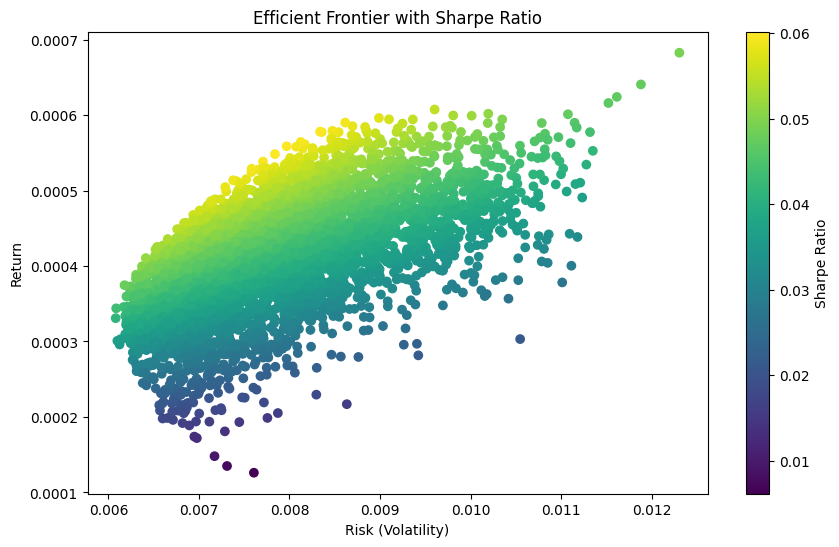

In [12]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(risk_list, returns_list, c=sharpe_list, cmap='viridis')

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")
plt.title("Efficient Frontier with Sharpe Ratio")

plt.colorbar(scatter, label="Sharpe Ratio")

plt.show()

## Optimales Portfolio

Wir bestimmen das Portfolio mit der höchsten Sharpe Ratio.

Dieses Portfolio maximiert die risikoadjustierte Rendite.

In [13]:
max_sharpe_idx = np.argmax(sharpe_list)

optimal_return = returns_list[max_sharpe_idx]
optimal_risk = risk_list[max_sharpe_idx]
optimal_weights = weights_list[max_sharpe_idx]

In [16]:
print("Optimal Portfolio Weights:")
for i, asset in enumerate(assets):
    print(asset, ":", round(optimal_weights[i], 4))

print("\nReturn:", optimal_return)
print("Risk:", optimal_risk)

Optimal Portfolio Weights:
SPY : 0.4841
QQQ : 0.2736
TLT : 0.2031
GLD : 0.0225
VNQ : 0.0166

Return: 0.0005586859071577396
Risk: 0.007969356912579165


## Visualisierung des optimalen Portfolios

Der rote Punkt zeigt das Portfolio mit der höchsten Sharpe Ratio.

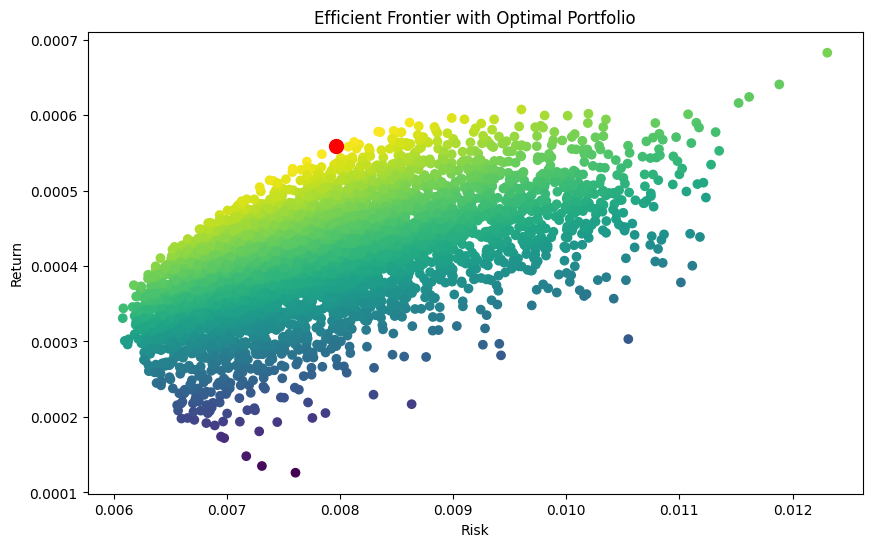

In [17]:
plt.figure(figsize=(10,6))

plt.scatter(risk_list, returns_list, c=sharpe_list, cmap='viridis')

plt.scatter(optimal_risk, optimal_return, color='red', s=100)

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Efficient Frontier with Optimal Portfolio")

plt.show()

## Erweiterung und Forschungsrichtung

Die klassische Markowitz-Theorie basiert auf historischen Daten und einfachen Annahmen.

In der Praxis gibt es jedoch mehrere Probleme:

- Instabilität der Kovarianzmatrix
- Schätzung der erwarteten Renditen ist unsicher
- Märkte verändern sich über die Zeit (Regimewechsel)

Daher ist das Ziel dieser Arbeit, moderne Methoden des Statistical Learning zu integrieren.

### Geplante Erweiterungen

Folgende Ansätze werden untersucht:

- Machine Learning zur Schätzung von Renditen
- Regularisierung der Kovarianzmatrix
- Zeitreihenmodelle (z.B. Regime Switching)
- Vergleich klassischer und moderner Methoden

### Ziel der Arbeit

Das Ziel ist es, ein robusteres Portfolio-Optimierungsmodell zu entwickeln,
das besser an reale Finanzmärkte angepasst ist.